# 🌾 Crop Yield Prediction System

---

## 1. Introduction / Problem Statement

Agricultural productivity is influenced by a complex interplay of environmental conditions (rainfall, temperature, humidity), soil characteristics, and farming practices (fertilizer use, irrigation). Farmers and agricultural planners often rely on experience and intuition to estimate expected crop yield — an approach that becomes unreliable as climate variability increases and farming operations scale up.

This project aims to build a **regression-based machine learning system** that predicts crop yield (in tons per hectare) using environmental and farming condition data. By learning patterns from historical data, the model can provide data-driven yield estimates that support better planning and decision-making across the agricultural value chain.

---


## 2. Objectives

- Analyze the relationship between environmental factors (rainfall, temperature, humidity) and crop yield.
- Understand how farming practices — soil type, fertilizer choice, and irrigation status — influence productivity.
- Engineer meaningful features from raw agricultural and climate data.
- Build and compare multiple regression models to predict crop yield accurately.
- Identify the most influential factors driving yield through feature importance analysis.
- Deliver an interactive interface where a user can input farming conditions and receive a real-time yield prediction.

---



## 3. Business / Real-World Impact

- **For farmers:** Enables better pre-season planning — choosing crops, fertilizers, and irrigation strategies suited to expected conditions, reducing guesswork and resource waste.
- **For agribusinesses & cooperatives:** Supports supply chain and procurement forecasting by estimating regional yield ahead of harvest.
- **For policymakers & agricultural agencies:** Assists in food security planning, subsidy allocation, and drought/flood risk preparedness by highlighting yield-sensitive regions.
- **For financial institutions (agri-lending/insurance):** Provides a data-driven basis for crop insurance risk assessment and loan planning.
- **Resource efficiency:** Better-informed fertilizer and irrigation usage reduces overuse, cutting costs and environmental impact.

---


## 4. About the Dataset

The dataset used in this project is a **synthetically generated agricultural dataset** designed to reflect realistic, domain-informed relationships between environmental/farming conditions and crop yield (rather than purely random data).

| Feature | Type | Description |
|---|---|---|
| `Rainfall_mm` | Numeric | Seasonal rainfall in millimeters |
| `Temperature_C` | Numeric | Average temperature in Celsius |
| `Humidity_%` | Numeric | Average relative humidity (%) |
| `Soil_Type` | Categorical | Loamy, Sandy, Clay, Silty, Peaty |
| `Crop_Type` | Categorical | Wheat, Rice, Maize, Sugarcane, Cotton, Soybean |
| `Fertilizer_Used` | Categorical | Urea, DAP, Compost, NPK, None |
| `Irrigation_Status` | Categorical | Yes / No |
| `Region` | Categorical | North, South, East, West, Central |
| `Crop_Yield_tons_per_hectare` | Numeric (Target) | Yield produced, in tons per hectare |

**Key characteristics:**
- ~5,000 records
- Built-in non-linear effects (e.g., rainfall and temperature both have an optimal "sweet spot" — too little or too much reduces yield)
- Interaction effects (e.g., irrigation matters more when rainfall is low)
- A small proportion (~1.5%) of missing values injected into select columns, simulating real-world data quality issues
- Yield scale varies significantly by crop (e.g., Sugarcane vs. Cotton), which is realistic and must be accounted for during analysis

---


## 5. ML Approach & Algorithms

This is a **supervised regression problem** — the target variable (`Crop_Yield_tons_per_hectare`) is continuous.

**Models to be built and compared:**

| Model | Purpose |
|---|---|
| **Linear Regression** | Baseline model; establishes a simple, interpretable benchmark |
| **Decision Tree Regressor** | Captures non-linear relationships and feature interactions |
| **Random Forest Regressor** | Ensemble of decision trees; expected to generalize best and provide feature importance insights |

**Evaluation metrics:**
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² Score (coefficient of determination)

---


## 6. Project Flow

```
1. Data Acquisition
   └── Load raw dataset, initial sanity checks

2. Exploratory Data Analysis (EDA)
   └── Univariate & bivariate analysis, correlation study, outlier detection

3. Data Preprocessing & Feature Engineering
   └── Handle missing values, encode categoricals, scale numerics,
       engineer new features, train/test split

4. Baseline Modeling
   └── Train & evaluate Linear Regression

5. Model Experimentation
   └── Train & tune Decision Tree and Random Forest Regressors
   └── Compare performance, analyze feature importance

6. Model Finalization
   └── Select best model, retrain on full data, serialize (.pkl)

7. UI Development
   └── Build interactive Streamlit app for real-time predictions

8. Documentation & Deployment
   └── Write README, polish notebook, optional cloud deployment
```

---



## 7. Tools & Libraries

- **Data handling:** pandas, numpy
- **Visualization:** matplotlib, seaborn
- **Modeling:** scikit-learn
- **Serialization:** joblib
- **UI:** Streamlit

---

*This notebook documents the end-to-end workflow for the Crop Yield Prediction System, from raw data to a deployable prediction interface.*


# Importing Libraries

In [ ]:
# For Data handling
import pandas as pd
import numpy as np

# For Visualization
import matplotlib.pyplot as plt
from matplotlib import axes
import seaborn as sns

# For Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

# For Modeling
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# For Evaluation
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV

# For Serialization
import joblib

# Settings for cleaner output
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_column", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("All Libraries Imported Successfully...")

All Libraries Imported Successfully...


# 1. Data Acquisition & Initial Sanity check

In [ ]:
# Data loading
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data sets/crop_yield_data.csv")
print(df.head(10))

   Rainfall_mm  Temperature_C  Humidity_% Soil_Type  Crop_Type  \
0       856.30          21.16       53.12     Silty  Sugarcane   
1       852.70          30.34       53.36     Loamy     Cotton   
2       565.27          24.03       47.84     Silty      Maize   
3       599.71          24.43       57.94     Silty     Cotton   
4      1048.52          33.24       65.55     Silty     Cotton   
5      1047.54          14.61       45.18     Loamy       Rice   
6      1009.25          20.87       48.33     Loamy      Maize   
7       650.18          27.23       46.38     Peaty      Maize   
8       836.29          26.98       53.01     Sandy      Maize   
9       450.42          18.49       52.46     Sandy     Cotton   

  Fertilizer_Used Irrigation_Status   Region  Crop_Yield_tons_per_hectare  
0            Urea                No    South                       74.431  
1             DAP               Yes    South                        2.998  
2             NPK               Yes  Central 

In [ ]:
print(df.tail(5))

      Rainfall_mm  Temperature_C  Humidity_% Soil_Type Crop_Type  \
4995       565.05          20.33       41.91     Loamy      Rice   
4996       746.97          31.73       54.04     Sandy     Maize   
4997       481.56          33.26       51.19     Silty      Rice   
4998       627.06          28.26       53.99     Loamy   Soybean   
4999       733.09          27.19       61.15     Sandy   Soybean   

     Fertilizer_Used Irrigation_Status   Region  Crop_Yield_tons_per_hectare  
4995             NaN               Yes  Central                        5.315  
4996             NPK               Yes     East                        5.931  
4997             DAP                No    North                        4.366  
4998             DAP                No     West                        3.782  
4999             NPK               Yes     West                        3.184  


In [ ]:
print(df.sample(5))

      Rainfall_mm  Temperature_C  Humidity_% Soil_Type  Crop_Type  \
1986       913.40          23.48       64.15     Silty      Wheat   
4469       962.65          32.98       46.45     Silty     Cotton   
2919       826.17          27.53       57.32     Peaty       Rice   
365        438.61          29.47         NaN     Loamy     Cotton   
4087       806.48          28.55       68.04      Clay  Sugarcane   

     Fertilizer_Used Irrigation_Status Region  Crop_Yield_tons_per_hectare  
1986         Compost                No   East                        3.320  
4469             DAP               Yes  South                        2.212  
2919             DAP               Yes  South                        5.256  
365          Compost               Yes   West                        2.352  
4087             NPK                No   West                       77.509  


In [ ]:
# Data_Shape checking
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (5000, 9)


In [ ]:
# Checking DataTypes
print("="* 55)
print(f"{' '*20} Data Types")
print("="* 55)
print(df.dtypes)

                     Data Types
Rainfall_mm                    float64
Temperature_C                  float64
Humidity_%                     float64
Soil_Type                       object
Crop_Type                       object
Fertilizer_Used                 object
Irrigation_Status               object
Region                          object
Crop_Yield_tons_per_hectare    float64
dtype: object


In [ ]:
 # Data Information
print("="* 55)
print(f"{' '*20} Data Information")
print("="* 55)
print(df.info(verbose=False))

                     Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 9 entries, Rainfall_mm to Crop_Yield_tons_per_hectare
dtypes: float64(4), object(5)
memory usage: 351.7+ KB
None


In [ ]:
# Exploring Columns
print("="* 55)
print(f"{' '*20} Columns")
print("="* 55)
print(df.columns)

                     Columns
Index(['Rainfall_mm', 'Temperature_C', 'Humidity_%', 'Soil_Type', 'Crop_Type',
       'Fertilizer_Used', 'Irrigation_Status', 'Region',
       'Crop_Yield_tons_per_hectare'],
      dtype='object')


In [ ]:
# Finding missing val
print("="* 55)
print(f"{' '*20} Missing Values")
print("="* 55)
df.isnull().sum()

                     Missing Values


,0
Rainfall_mm,75
Temperature_C,75
Humidity_%,75
Soil_Type,75
Crop_Type,0
Fertilizer_Used,483
Irrigation_Status,0
Region,0
Crop_Yield_tons_per_hectare,0


In [ ]:
# Percentage missing per Column
print("="* 55)
print(f"{' '*20} %Age Missing Per Column")
print("="* 55)
df.isnull().mean()* 100

                     %Age Missing Per Column


,0
Rainfall_mm,1.50
Temperature_C,1.50
Humidity_%,1.50
Soil_Type,1.50
Crop_Type,0.00
Fertilizer_Used,9.66
Irrigation_Status,0.00
Region,0.00
Crop_Yield_tons_per_hectare,0.00


In [ ]:
# Checking wether missing values are random or limited to specific rows
m = df[df.isnull().any(axis =1)].head()
print(m)

    Rainfall_mm  Temperature_C  Humidity_% Soil_Type  Crop_Type  \
6       1009.25          20.87       48.33     Loamy      Maize   
25       852.44          19.88       57.93      Clay     Cotton   
27       576.57          31.18       48.10      Clay      Wheat   
29       707.27          34.59       50.32      Clay      Maize   
38       538.11          22.77       64.63       NaN  Sugarcane   

   Fertilizer_Used Irrigation_Status   Region  Crop_Yield_tons_per_hectare  
6              NaN               Yes    South                        5.157  
25             NaN               Yes    South                        2.021  
27             NaN               Yes  Central                        2.675  
29             NaN                No  Central                        4.273  
38             NPK               Yes  Central                      100.134  


In [ ]:
# checking Duplicated Values
df.duplicated().sum()

np.int64(0)

In [ ]:
# Describing Numerical Dataset
print("="* 55)
print(f"{' '*15} Numerical Data Description")
print("="* 55)
print(df.describe())

                Numerical Data Description
       Rainfall_mm  Temperature_C   Humidity_%  Crop_Yield_tons_per_hectare
count  4925.000000    4925.000000  4925.000000                  5000.000000
mean    760.882705      27.058629    55.097295                    15.094867
std     221.037613       5.033955     9.269357                    25.637362
min     103.310000      10.000000    22.370000                     0.861000
25%     597.680000      23.610000    48.890000                     2.775750
50%     750.650000      27.080000    55.070000                     3.864500
75%     925.480000      30.470000    61.420000                     6.195000
max    1497.650000      45.000000    88.910000                   106.569000


In [ ]:
# Describing categorical Data
print("="* 55)
print(f"{' '*15} Categorical Data Description")
print("="* 55)
print(df.describe(include="object"))

                Categorical Data Description
       Soil_Type Crop_Type Fertilizer_Used Irrigation_Status Region
count       4925      5000            4517              5000   5000
unique         5         6               4                 2      5
top        Sandy     Wheat             NPK               Yes  South
freq        1049       870            1299              3033   1042


In [ ]:
# Unique Values in Categorical Columns
print("="* 55)
print(f"{' '*15} Unique Values Per Column")
print("="* 55)
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].unique()}")

                Unique Values Per Column
Soil_Type: ['Silty' 'Loamy' 'Peaty' 'Sandy' 'Clay' nan]
Crop_Type: ['Sugarcane' 'Cotton' 'Maize' 'Rice' 'Soybean' 'Wheat']
Fertilizer_Used: ['Urea' 'DAP' 'NPK' nan 'Compost']
Irrigation_Status: ['No' 'Yes']
Region: ['South' 'Central' 'East' 'North' 'West']


In [ ]:
# Range & Domain Validity Checks
print("="* 55)
print(f"{' '*15} Range & Domain Validity Checks")
print("="* 55)

print(f"Rainfall_mm: ",  df['Rainfall_mm'].min(), "--", df['Rainfall_mm'].max())
print(f"Temperature_C:",  df['Temperature_C'].min(), "--", df['Temperature_C'].max())
print(f"Humidity_%:",     df['Humidity_%'].min(),"--", df['Humidity_%'].max())
print(f"Crop_Yield_tons_per_hectare:",  df['Crop_Yield_tons_per_hectare'].min(), "--", df['Crop_Yield_tons_per_hectare'].max())

                Range & Domain Validity Checks
Rainfall_mm:  103.31 -- 1497.65
Temperature_C: 10.0 -- 45.0
Humidity_%: 22.37 -- 88.91
Crop_Yield_tons_per_hectare: 0.861 -- 106.569


In [ ]:
# Target Variable Check
print("="* 55)
print(f"{' '*15} Target Variable Check")
print("="* 55)
print(df.Crop_Yield_tons_per_hectare.describe())
print(f"Null values are: {df['Crop_Yield_tons_per_hectare'].isnull().sum()}")

                Target Variable Check
count    5000.000000
mean       15.094867
std        25.637362
min         0.861000
25%         2.775750
50%         3.864500
75%         6.195000
max       106.569000
Name: Crop_Yield_tons_per_hectare, dtype: float64
Null values are: 0


In [ ]:
# Class Balance (Categorical Features)
for col in ["Soil_Type", "Crop_Type", "Fertilizer_Used", "Irrigation_Status", "Region"]:
    print(df[col].value_counts(normalize=True)* 100)
    print("--"*50)

Soil_Type
Sandy    21.299492
Loamy    19.918782
Peaty    19.857868
Silty    19.736041
Clay     19.187817
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
Crop_Type
Wheat        17.40
Cotton       17.04
Sugarcane    16.84
Soybean      16.42
Maize        16.24
Rice         16.06
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
Fertilizer_Used
NPK        28.758025
Urea       26.566305
DAP        23.024131
Compost    21.651539
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
Irrigation_Status
Yes    60.66
No     39.34
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
Region
South      20.84
North      20.64
Central    19.70
East       19.48
West       19.34

In [ ]:
#  Memory & Performance Check
print("="* 55)
print(f"{' '*15} Memory & Performance Check")
print("="* 55)
print(df.info(memory_usage="deep"))

                Memory & Performance Check
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rainfall_mm                  4925 non-null   float64
 1   Temperature_C                4925 non-null   float64
 2   Humidity_%                   4925 non-null   float64
 3   Soil_Type                    4925 non-null   object 
 4   Crop_Type                    5000 non-null   object 
 5   Fertilizer_Used              4517 non-null   object 
 6   Irrigation_Status            5000 non-null   object 
 7   Region                       5000 non-null   object 
 8   Crop_Yield_tons_per_hectare  5000 non-null   float64
dtypes: float64(4), object(5)
memory usage: 1.4 MB
None


In [ ]:
# Quick all-in-one Snapshot
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)
print("\nNumeric summary:\n", df.describe())

Shape: (5000, 9)

Missing values:
 Rainfall_mm                     75
Temperature_C                   75
Humidity_%                      75
Soil_Type                       75
Crop_Type                        0
Fertilizer_Used                483
Irrigation_Status                0
Region                           0
Crop_Yield_tons_per_hectare      0
dtype: int64

Duplicates: 0

Data types:
 Rainfall_mm                    float64
Temperature_C                  float64
Humidity_%                     float64
Soil_Type                       object
Crop_Type                       object
Fertilizer_Used                 object
Irrigation_Status               object
Region                          object
Crop_Yield_tons_per_hectare    float64
dtype: object

Numeric summary:
        Rainfall_mm  Temperature_C   Humidity_%  Crop_Yield_tons_per_hectare
count  4925.000000    4925.000000  4925.000000                  5000.000000
mean    760.882705      27.058629    55.097295                    15.094

# 🔍 Data Observations & Initial Diagnosis

Based on the initial data acquisition and sanity checks, here are some key observations:

*   **Missing Values in `Fertilizer_Used` (483 records):** This is a critical observation. The count of 483 missing values is highly suspicious, aligning almost perfectly with 10% of the 5,000 records. Given that the dataset description mentioned a 'None' category for fertilizer usage with a 10% probability, it's highly probable that `pd.read_csv()` implicitly interpreted these legitimate "None" strings as `NaN` (Not a Number) values. This indicates that these are not truly missing data points but rather a valid farming choice that needs to be properly re-categorized as 'None' instead of `NaN`.

*   **Missing Values in other Numeric/Categorical Columns (75 records each):** The columns `Rainfall_mm`, `Temperature_C`, `Humidity_%`, and `Soil_Type` each have 75 missing values (1.5%). Unlike `Fertilizer_Used`, these appear to be genuine missing data points that will require imputation during the preprocessing phase.

*   **Yield Range and Potential Outliers (`Crop_Yield_tons_per_hectare`):** The `Crop_Yield_tons_per_hectare` column shows a wide range, with a maximum value of approximately 106.57 tons/hectare, which is significantly higher than the mean of 15.09 tons/hectare. While this might initially suggest outliers, it's important to remember the dataset's characteristic: Sugarcane naturally has much higher yields (60-100+ t/ha) compared to other crops (2-6 t/ha). Therefore, this high maximum value is likely valid for Sugarcane and should not be treated as an anomaly without further crop-specific analysis.

# 2. Exploratory Data Analysis [EDA]

In [ ]:
# Defining columns
num_cols = ["Rainfall_mm", "Temperature_C", "Humidity_%", "Crop_Yield_tons_per_hectare"]
cat_cols = ["Soil_Type", "Crop_Type", "Fertilizer_Used", "Irrigation_Status", "Region"]

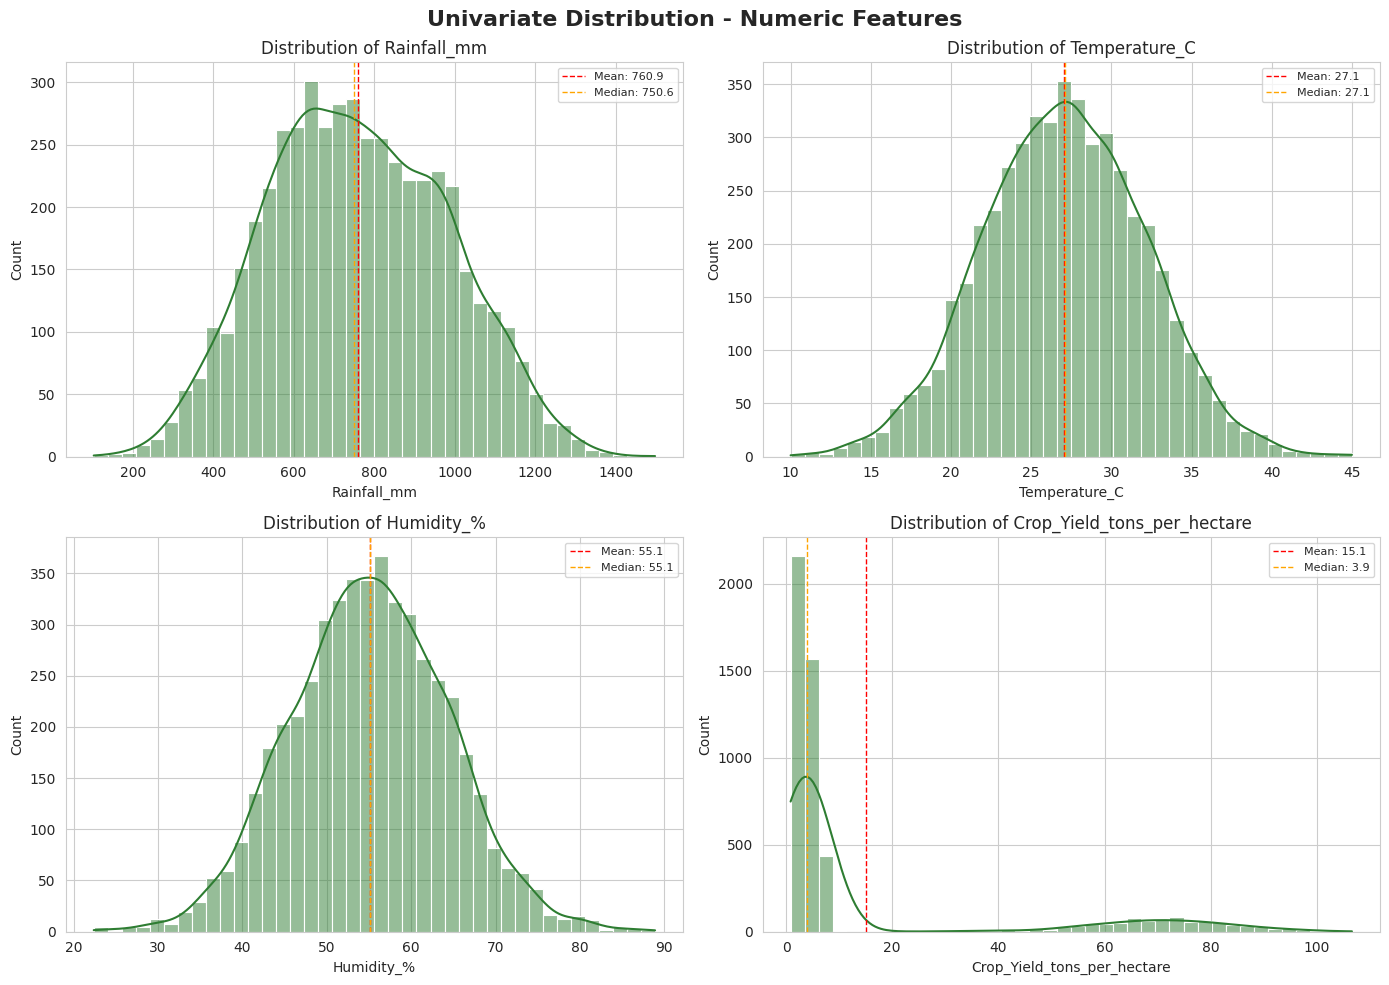

In [ ]:
# Univariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Univariate Distribution - Numeric Features",
             fontsize=16, fontweight="bold")

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, color="#2e7d32", ax=ax, bins= 40)
    ax.set_title(f"Distribution of {col}")
    ax.axvline(df[col].mean(), color="red", linestyle="dashed",
               linewidth=1, label=f"Mean: {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="orange", linestyle="dashed",
               linewidth=1, label=f"Median: {df[col].median():.1f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Observations (Univariate Distribution - Numeric Features):
- **Rainfall_mm**: Appears to be slightly right-skewed, with most rainfall events concentrated between 600-1000mm.
- **Temperature_C**: Shows a relatively normal distribution, centered around 25-30°C.
- **Humidity_%**: Also appears relatively normally distributed, with a slight left skew.
- **Crop_Yield_tons_per_hectare**: Highly right-skewed, indicating that most crops have lower yields, but there are a few instances of very high yields (likely sugarcane), which aligns with the initial data description. This confirms the need to handle different yield scales across crop types.

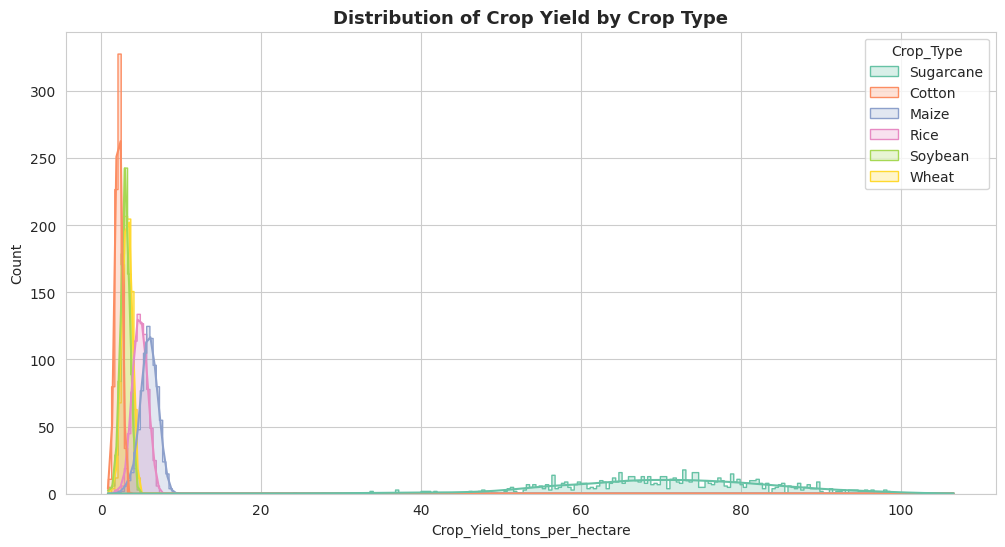

In [ ]:
# yield distribution per crop
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x= "Crop_Yield_tons_per_hectare", kde=True, hue="Crop_Type",
             element="step", palette="Set2")
plt.title("Distribution of Crop Yield by Crop Type", fontsize=13, fontweight="bold")

plt.tight_layout
plt.show()

#### Observations (Yield Distribution by Crop Type):
- This plot clearly shows the significant difference in yield scale between `Sugarcane` and other crops. Sugarcane yields are much higher and spread over a wider range.
- Other crops like `Cotton`, `Maize`, `Rice`, `Soybean`, and `Wheat` have relatively lower and more clustered yield distributions.

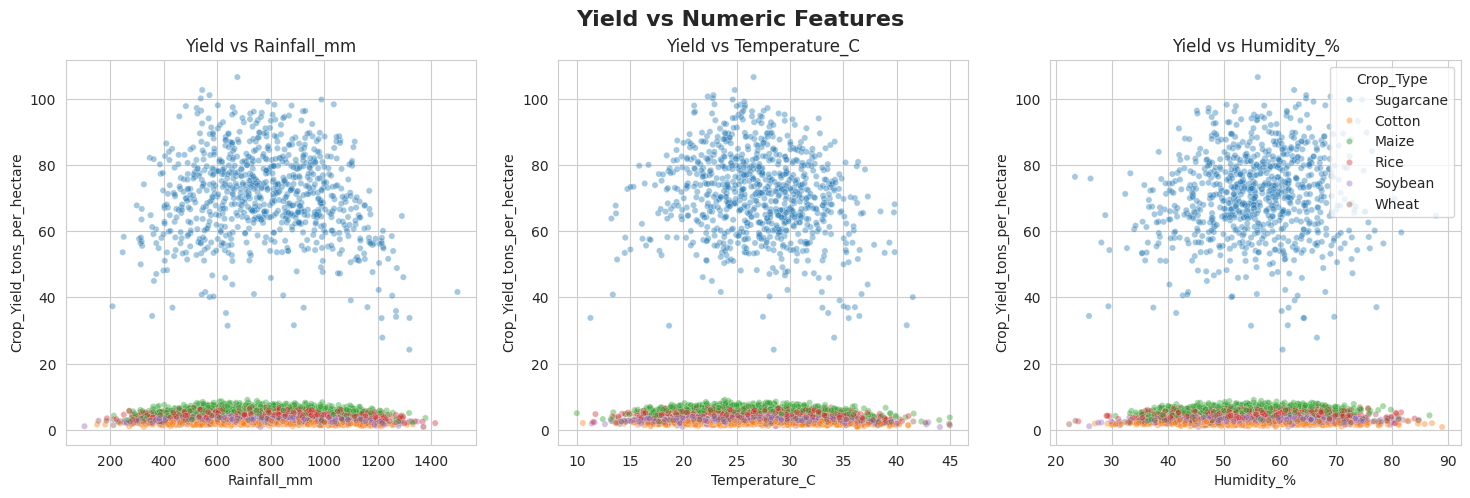

In [ ]:
from numpy._core import numeric
# ==========================================================
# 2. BIVARIATE ANALYSIS - Numeric vs Yield (scatter)
# ==========================================================
numeric_features = ["Rainfall_mm", "Temperature_C", "Humidity_%"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Yield vs Numeric Features", fontsize=16, fontweight="bold")

for ax, col in zip(axes.flatten(), numeric_features):
    sns.scatterplot(data=df, x=col, y="Crop_Yield_tons_per_hectare", ax=ax, hue="Crop_Type",
                    alpha=0.4, s=20, palette="tab10", legend=(col=="Humidity_%"))
    ax.set_title(f"Yield vs {col}")

plt.tight_layout
plt.savefig("Yield_vs_numeric_scatter.png", bbox_inches="tight")
plt.show()

#### Observations (Yield vs Numeric Features - Scatter):
- **Rainfall_mm vs Yield**: No clear linear correlation is visible when all crop types are pooled together. The spread suggests non-linear relationships or different optimal ranges for different crops.
- **Temperature_C vs Yield**: Similar to rainfall, no strong linear pattern overall. High yields (sugarcane) appear across various temperature ranges, but other crops are more clustered.
- **Humidity_% vs Yield**: Again, no strong overall linear correlation. The plot indicates complex interactions rather than simple direct relationships.

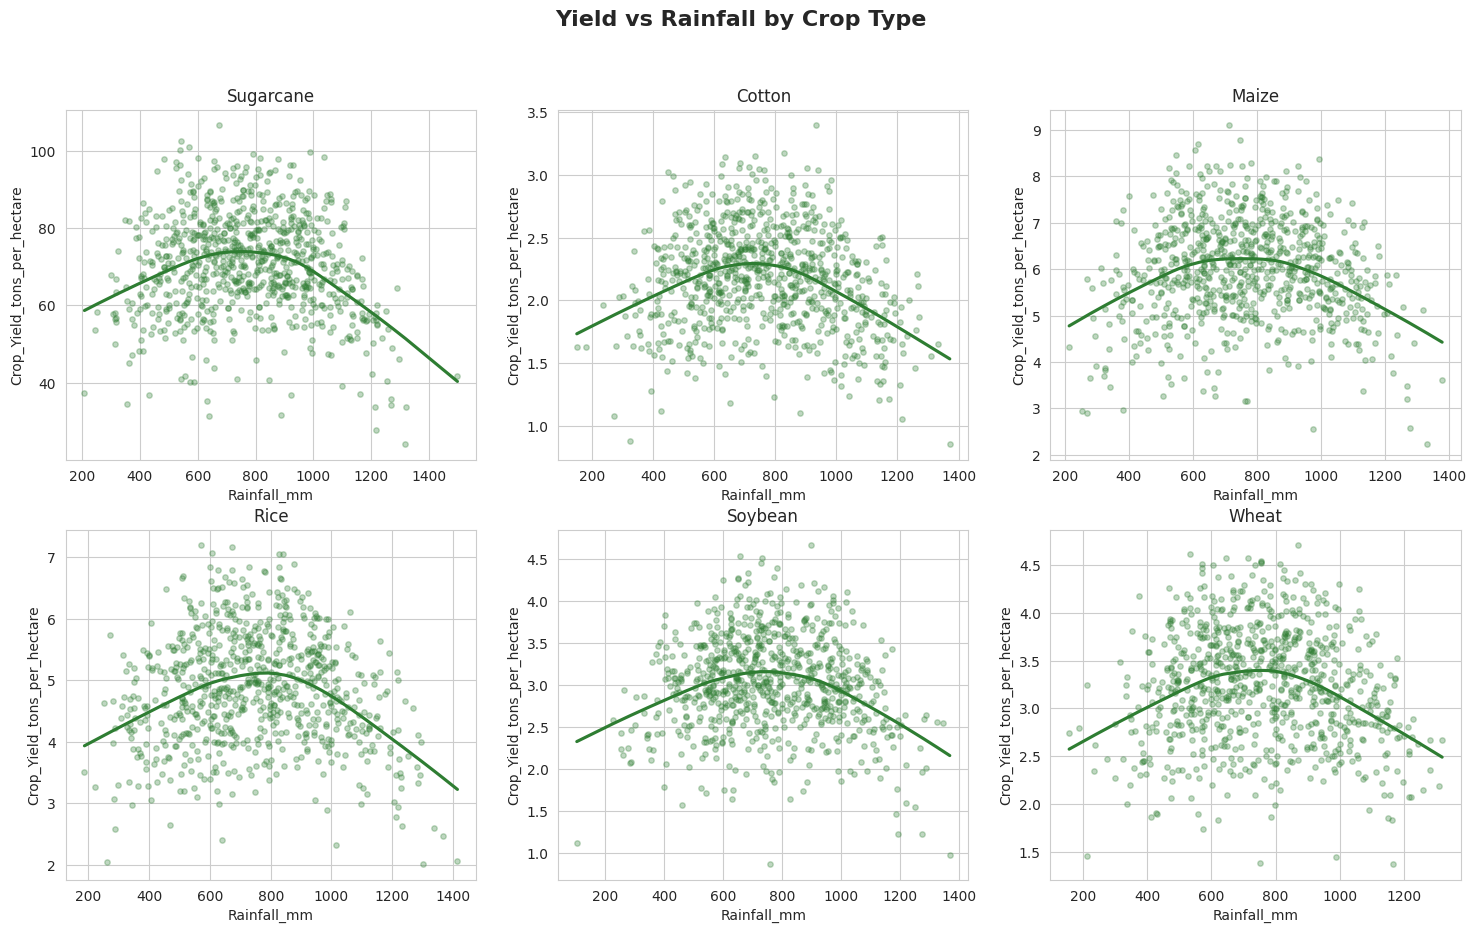

In [ ]:
# Same scatter but faceted by crop, with a trend line, to see the true non-linear pattern per crop

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Yield vs Rainfall by Crop Type", fontsize=16, fontweight="bold")

crops = df["Crop_Type"].unique()

for ax, crop in zip(axes.flat, crops):
    subset = df[df["Crop_Type"] == crop]
    sns.regplot(data = subset, x = "Rainfall_mm", y= "Crop_Yield_tons_per_hectare",
                ax=ax, scatter_kws={"alpha": 0.3, "s": 15},
                lowess=True, color="#2e7d32")
    ax.set_title(crop)


plt.tight_layout
plt.show()

#### Observations (Yield vs Rainfall by Crop Type - Faceted):
- This faceted view confirms the non-linear, optimal 'sweet spot' effect mentioned in the dataset description for some crops. For example, some crops might have an optimal rainfall range, with yield decreasing outside of it.
- The relationships between rainfall and yield are distinct for each crop type, highlighting the importance of considering `Crop_Type` in the model.

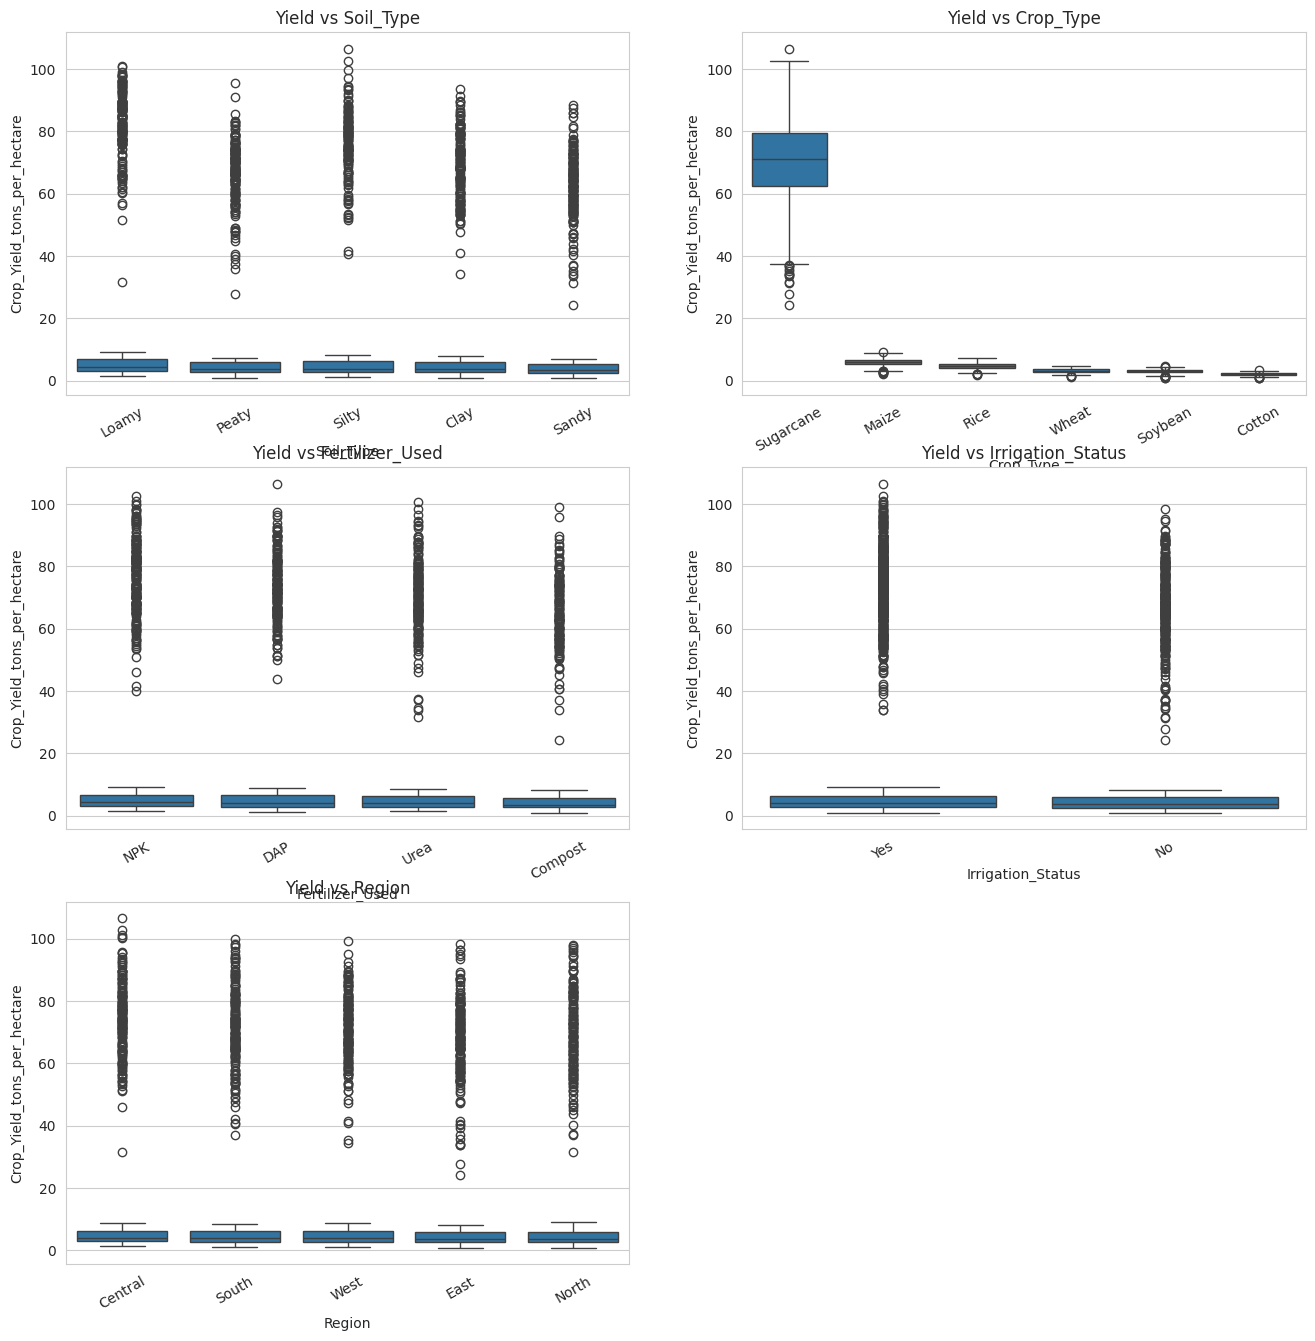

In [ ]:
# ==========================================================
# 2b. BIVARIATE ANALYSIS - Categorical vs Yield (boxplots)
# ==========================================================

fig, axes = plt.subplots(3, 2, figsize=(16,16))

for ax, col in zip(axes.flat, cat_cols):
    order = df.groupby(col)["Crop_Yield_tons_per_hectare"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x= col, y= "Crop_Yield_tons_per_hectare", ax=ax, order=order)
    ax.set_title(f"Yield vs {col}")
    ax.tick_params(axis="x", rotation=30)

axes.flat[-1].axis("off")
plt.tight_layout
plt.show()

#### Observations (Categorical vs Yield - Boxplots):
- **Soil_Type**: Shows varying median yields across soil types, suggesting `Soil_Type` is an important factor. 'Silty' and 'Peaty' soils appear to be associated with higher median yields, but the ranges vary.
- **Crop_Type**: Reconfirms that `Sugarcane` has significantly higher yields and a wider distribution compared to other crops.
- **Fertilizer_Used**: Different fertilizers show distinct yield distributions, implying `Fertilizer_Used` impacts yield. 'Urea' and 'NPK' seem to correlate with higher median yields.
- **Irrigation_Status**: Crops with 'Yes' irrigation status generally show higher median yields and potentially narrower distributions than 'No' irrigation, indicating the importance of irrigation.
- **Region**: Yield distributions vary across different regions, suggesting regional effects or different dominant crop types/practices in each region.

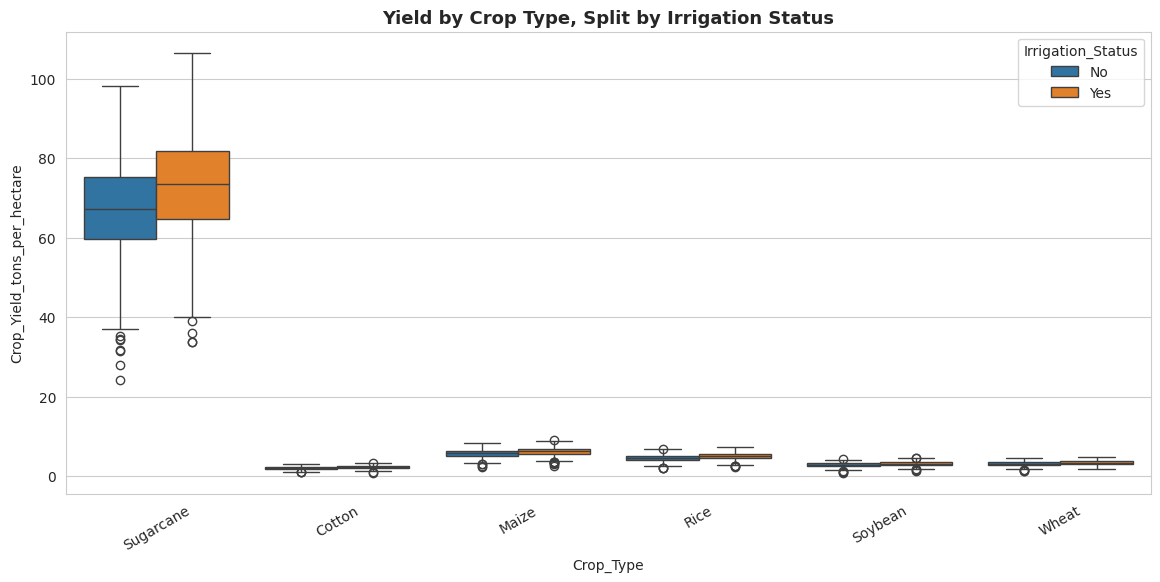

In [ ]:
# Yield by Crop Type, Split by Irrigation Status

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="Crop_Type", y="Crop_Yield_tons_per_hectare", hue="Irrigation_Status")
plt.title("Yield by Crop Type, Split by Irrigation Status", fontsize=13, fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout
plt.show()

#### Observations (Yield by Crop Type, Split by Irrigation Status):
- For most crop types, 'Yes' irrigation status is associated with higher median yields and often a tighter distribution, indicating more consistent yields.
- The impact of irrigation varies by crop. For example, sugarcane shows a clear increase in yield with irrigation, while other crops might show a smaller, but still present, difference. This confirms that irrigation is a critical factor.

In [ ]:
df_numeric = df[num_cols]
df_numeric.head()


,Rainfall_mm,Temperature_C,Humidity_%,Crop_Yield_tons_per_hectare
0,856.30,21.16,53.12,74.431
1,852.70,30.34,53.36,2.998
2,565.27,24.03,47.84,7.407
3,599.71,24.43,57.94,2.551
4,1048.52,33.24,65.55,1.941


In [ ]:
# Checking all the numeric columns are float64 before correlation heatmap
df_numeric.dtypes

,0
Rainfall_mm,float64
Temperature_C,float64
Humidity_%,float64
Crop_Yield_tons_per_hectare,float64


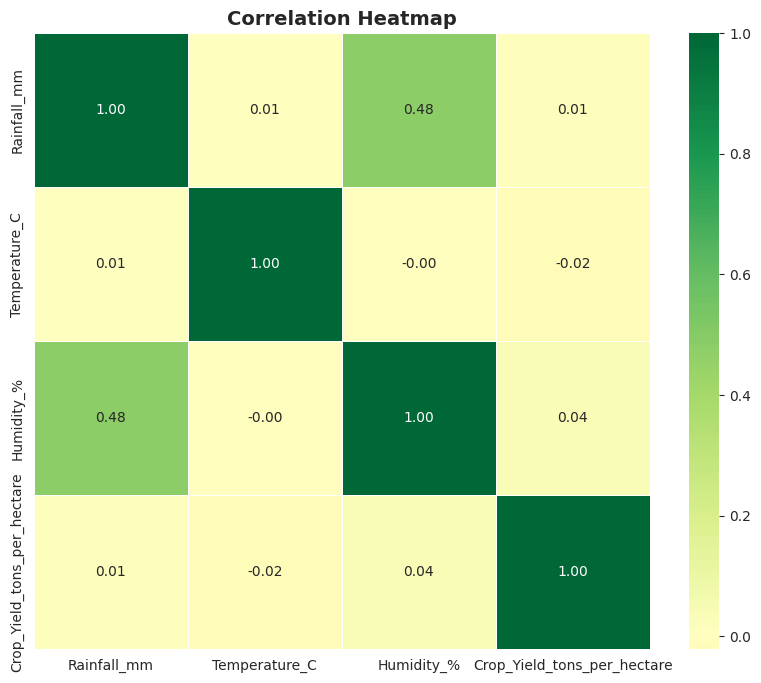

In [ ]:
  # Correlation heatmap
corr = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            square=True,
            linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout
plt.show()


#### Observations (Correlation Heatmap):
- When considering all numerical features pooled together, the correlations with `Crop_Yield_tons_per_hectare` are very low (close to zero).
- This low pooled correlation is misleading, as previously observed in the faceted plots. It suggests that linear relationships are not strong globally, and that the effect of these variables on yield is highly dependent on `Crop_Type` or other interacting factors.

In [ ]:
corr_yield = corr["Crop_Yield_tons_per_hectare"].sort_values(ascending=False)
print(corr_yield)

Crop_Yield_tons_per_hectare    1.000000
Humidity_%                     0.040066
Rainfall_mm                    0.012868
Temperature_C                 -0.021081
Name: Crop_Yield_tons_per_hectare, dtype: float64


In [ ]:
# comparing the pooled_correlation vs pre-crop correlation
print("="* 55)
print(f"{' '*15} Pooled Correlation")
print("="* 55)
print(corr["Crop_Yield_tons_per_hectare"])

print("\n\n")
print("="* 55)
print(f"{' '*15} Pre-Crop Correlation")
print("="* 55)
print("\nWithin Sugarcane only:")
sugarcane = df[df["Crop_Type"] == "Sugarcane"][num_cols]
print(sugarcane.corr()["Crop_Yield_tons_per_hectare"])

                Pooled Correlation
Rainfall_mm                    0.012868
Temperature_C                 -0.021081
Humidity_%                     0.040066
Crop_Yield_tons_per_hectare    1.000000
Name: Crop_Yield_tons_per_hectare, dtype: float64



                Pre-Crop Correlation

Within Sugarcane only:
Rainfall_mm                   -0.111114
Temperature_C                 -0.166390
Humidity_%                     0.101771
Crop_Yield_tons_per_hectare    1.000000
Name: Crop_Yield_tons_per_hectare, dtype: float64


#### Observations (Pooled vs Pre-Crop Correlation):
- The comparison between pooled correlation and correlation within 'Sugarcane' highlights a crucial point: relationships between environmental factors and yield are crop-specific.
- For `Sugarcane`, `Rainfall_mm` and `Temperature_C` show negative correlations, and `Humidity_%` shows a positive correlation. This is in contrast to the near-zero correlations when all crops are pooled.
- This observation reinforces the need for models that can capture these crop-specific interactions, or for careful feature engineering to account for these dependencies.

In [ ]:
# Outlier Detection via IQR method
def iqr_outlier_detection(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound



for col in ["Rainfall_mm", "Temperature_C", "Humidity_%"]:
    outliers, low, high = iqr_outlier_detection(df[col])
    print(f"{col}: {len(outliers)} outliers, valid range [{low: .1f}, {high: .1f}]",
          f"actual range [{df[col].min(): .1f}, {df[col].max():.1f}]")


Rainfall_mm: 2 outliers, valid range [ 106.0,  1417.2] actual range [ 103.3, 1497.7]
Temperature_C: 29 outliers, valid range [ 13.3,  40.8] actual range [ 10.0, 45.0]
Humidity_%: 45 outliers, valid range [ 30.1,  80.2] actual range [ 22.4, 88.9]


#### Observations (Outlier Detection via IQR method):
- **Rainfall_mm**: Has 2 detected outliers. The actual range is very close to the valid range, suggesting these are not extreme anomalies, but rather high rainfall events.
- **Temperature_C**: Has 29 detected outliers. The actual range extends beyond the valid range, indicating some temperature values are considered outliers by this method.
- **Humidity_%**: Has 45 detected outliers. The actual range also extends beyond the valid range, suggesting some extreme humidity values exist.
- These outliers should be handled carefully, as they might represent valid extreme environmental conditions rather than data errors. The boxplots will provide a visual confirmation.

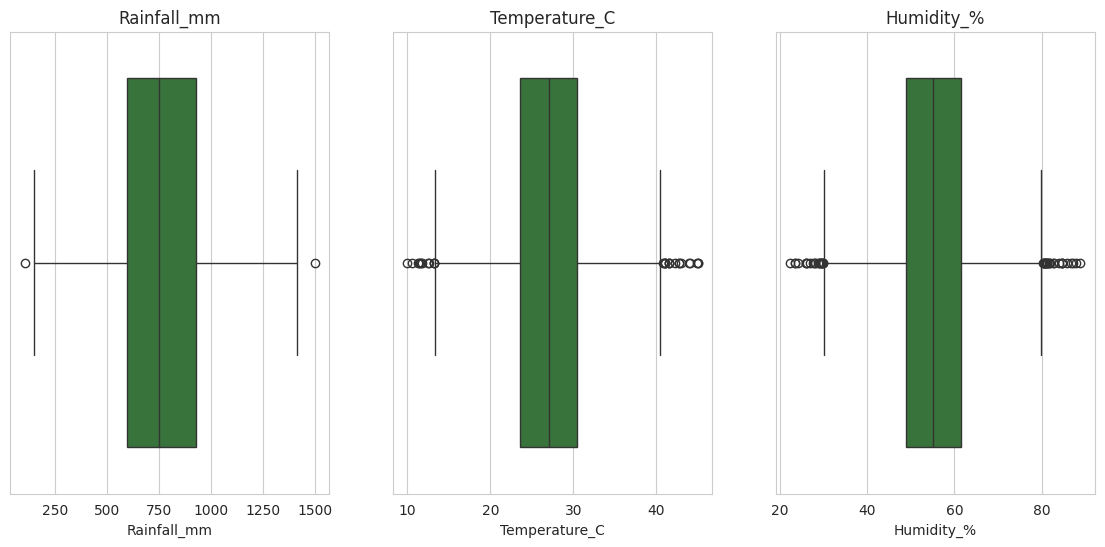

In [ ]:
# visualizing with boxplots
fig, axes = plt.subplots(1, 3, figsize = (14, 6))

for ax, col in zip(axes, ["Rainfall_mm", "Temperature_C", "Humidity_%"]):
    sns.boxplot(data=df, x=col, ax=ax, color="#2e7d32")
    ax.set_title(col)

plt.tight_layout
plt.show()



#### Observations (Outlier Visualization - Boxplots):
- The boxplots visually confirm the presence of outliers in `Rainfall_mm`, `Temperature_C`, and `Humidity_%` as identified by the IQR method.
- For `Rainfall_mm`, the outliers are at the higher end, consistent with very heavy rainfall.
- For `Temperature_C`, outliers are present at both lower and higher ends, indicating extreme cold and hot temperatures.
- For `Humidity_%`, outliers are present at both ends, indicating very low and very high humidity levels.
- These outliers are likely valid data points representing extreme weather conditions that could impact crop yield and should ideally be retained and handled by robust models rather than simply removed.

# 3. Data preprocessing & Feature Engineering

**Handling Missing Values**

In [ ]:
# Handling 483 missing values in Fertilizer_used column
df['Fertilizer_Used'] = df['Fertilizer_Used'].fillna("None")
print("Total null values in Fertilizer_Used column: ", df['Fertilizer_Used'].isnull().sum())
print("="* 55)
print(f"{' '*15} Fertilizer_Used")
print("="* 55)
print(df['Fertilizer_Used'].value_counts())

Total null values in Fertilizer_Used column:  0
                Fertilizer_Used
Fertilizer_Used
NPK        1299
Urea       1200
DAP        1040
Compost     978
None        483
Name: count, dtype: int64


#### Observations (Fertilizer_Used Missing Value Handling):
- The 483 missing values (9.66%) in `Fertilizer_Used` were successfully filled with the string 'None'. This addresses the initial hypothesis that these were not true missing values but rather an implicit 'None' category interpreted as `NaN` by pandas.
- The `value_counts()` now correctly shows 'None' as a distinct category, confirming the successful re-categorization.

In [ ]:
# Rechecking the true missingness
df.isnull().sum()

,0
Rainfall_mm,75
Temperature_C,75
Humidity_%,75
Soil_Type,75
Crop_Type,0
Fertilizer_Used,0
Irrigation_Status,0
Region,0
Crop_Yield_tons_per_hectare,0


In [ ]:
# verifying the yield is real or corrupted
print("="* 55)
print(f"{' '*15} Crop_Yield_tons_per_hectare")
print("="* 55)
df.groupby("Crop_Type")["Crop_Yield_tons_per_hectare"].agg(["min", "max", "mean"])

                Crop_Yield_tons_per_hectare


,min,max,mean
Crop_Type,,,
Cotton,0.861,3.392,2.178919
Maize,2.241,9.095,5.983349
Rice,2.017,7.193,4.856496
Soybean,0.874,4.657,3.021555
Sugarcane,24.253,106.569,70.732910
Wheat,1.375,4.706,3.243499


# Observation

The maximum yield is from sugarcan crop. That's normal in real world yield.
Normally, sugarcane yield vary from 90-100+ tn/ha

In [ ]:
# Data cleaning of Numerical Columns
print("="* 55)
print(f"{' '*15} Numerical Data Cleaning")
print("="* 55)

"""

Since yield-driving numeric features vary meaningfully by Region/Crop,
group-based imputation is more accurate:

"""
for col in ['Rainfall_mm', 'Temperature_C', 'Humidity_%']:
    df[col] = df.groupby(['Region', 'Crop_Type'])[col].transform(lambda x: x.fillna(x.median()))

print(df.isnull().sum())


                Numerical Data Cleaning
Rainfall_mm                     0
Temperature_C                   0
Humidity_%                      0
Soil_Type                      75
Crop_Type                       0
Fertilizer_Used                 0
Irrigation_Status               0
Region                          0
Crop_Yield_tons_per_hectare     0
dtype: int64


#### Observations (Numerical Data Cleaning):
- Missing values in `Rainfall_mm`, `Temperature_C`, and `Humidity_%` were imputed using the median specific to each `Region` and `Crop_Type` combination.
- This group-based imputation strategy is chosen to preserve the crop-specific and regional nuances observed during EDA, which is crucial given the non-linear relationships identified earlier.
- All numerical columns now have 0 missing values.

In [ ]:
# Categorical Data cleaning
print("="* 55)
print(f"{' '*15} Categorical Data Cleaning")
print("="* 55)

df['Soil_Type'] = df['Soil_Type'].fillna("Unknown")
print(df.isnull().sum())

                Categorical Data Cleaning
Rainfall_mm                    0
Temperature_C                  0
Humidity_%                     0
Soil_Type                      0
Crop_Type                      0
Fertilizer_Used                0
Irrigation_Status              0
Region                         0
Crop_Yield_tons_per_hectare    0
dtype: int64


#### Observations (Categorical Data Cleaning - Soil_Type):
- The 75 missing values in `Soil_Type` were imputed with 'Unknown'. This approach allows the model to learn if the 'Unknown' category has any specific relationship with crop yield without discarding data points.
- All columns in the DataFrame now have 0 missing values, completing the missing data handling phase.

**Feature Engineering**

In [ ]:
# Encode categorical variables (One-Hot for Soil Type, Crop Type, Fertilizer, Region)
categorical_cols = ['Soil_Type', 'Crop_Type', 'Fertilizer_Used', 'Region']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encoding Irrigation_Status via mapping method
df_encoded['Irrigation_Status'] = df_encoded['Irrigation_Status'].map({'Yes': 1, 'No': 0})

print(df_encoded.head(10))
print(df_encoded.dtypes)

   Rainfall_mm  Temperature_C  Humidity_%  Irrigation_Status  \
0       856.30          21.16       53.12                  0   
1       852.70          30.34       53.36                  1   
2       565.27          24.03       47.84                  1   
3       599.71          24.43       57.94                  1   
4      1048.52          33.24       65.55                  0   
5      1047.54          14.61       45.18                  0   
6      1009.25          20.87       48.33                  1   
7       650.18          27.23       46.38                  1   
8       836.29          26.98       53.01                  0   
9       450.42          18.49       52.46                  0   

   Crop_Yield_tons_per_hectare  Soil_Type_Loamy  Soil_Type_Peaty  \
0                       74.431            False            False   
1                        2.998             True            False   
2                        7.407            False            False   
3                      

#### Observations (Feature Engineering - Encoding):
- Categorical features (`Soil_Type`, `Crop_Type`, `Fertilizer_Used`, `Region`) were successfully converted into numerical format using One-Hot Encoding (`pd.get_dummies`). `drop_first=True` was used to avoid multicollinearity.
- `Irrigation_Status` was directly mapped to 0 and 1, as it is a binary categorical feature.
- The `df_encoded.head(10)` and `df_encoded.dtypes` outputs confirm that the encoding was applied correctly, creating new boolean columns for each category and converting `Irrigation_Status` to integer type.

In [ ]:
# Train/test split
x = df_encoded.drop('Crop_Yield_tons_per_hectare', axis=1)
y = df_encoded['Crop_Yield_tons_per_hectare']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Features shape: {x.shape}")
print(f"Target shape: {y.shape}")
print(f"Target classes: {y.unique()}")

Features shape: (5000, 22)
Target shape: (5000,)
Target classes: [74.431  2.998  7.407 ...  5.315  5.931  4.366]


#### Observations (Train/Test Split):
- The dataset was successfully split into training (80%) and testing (20%) sets for both features (`x`) and the target variable (`y`).
- The shapes of `x` and `y` confirm the correct dimensions, and the target variable (`Crop_Yield_tons_per_hectare`) is confirmed to be continuous, as expected for a regression problem.

In [ ]:
# feature scaling
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Feature scalling done successfully...")

Feature scalling done successfully...


#### Observations (Feature Scaling):
- Numerical features in both the training and testing sets were successfully scaled using `StandardScaler`.
- Scaling is a crucial step for many machine learning algorithms (like Linear Regression) to ensure that features with larger values do not disproportionately influence the model's learning process.
- The output confirms that the scaling process was completed.

# 4. Baseline Modeling



In [ ]:
# Train Linear Regression as baseline
lr_model = LinearRegression()
lr_model.fit(x_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [ ]:
# Evaluate with RMSE, MAE, R²

y_pred = lr_model.predict(x_test_scaled)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 4.65
MAE: 2.48
R²: 0.96


#### Observations (Linear Regression Baseline Model Evaluation):
- **RMSE (Root Mean Squared Error):** The value of 4.65 indicates that, on average, the model's predictions are about 4.65 tons/hectare away from the actual crop yield. Given the wide range of yields (from ~1 to ~106 tons/hectare), this suggests a decent but not perfect fit.
- **MAE (Mean Absolute Error):** An MAE of 2.48 means the average absolute difference between predicted and actual yields is 2.48 tons/hectare. This is a more interpretable metric than RMSE and shows reasonable accuracy.
- **R² Score:** A high R² value of 0.96 (96%) suggests that the Linear Regression model explains a significant portion of the variance in crop yield. This indicates that even a simple linear model can capture a large part of the underlying patterns in the data, likely due to the strong influence of 'Crop_Type' on yield magnitude.

In [ ]:
# Logging Baseline Score
results = pd.DataFrame(columns=["Model", "RMSE", "MAE", "R2"])
results.loc[len(results)] = ["Linear Regression", rmse, mae, r2]
print(results)


               Model      RMSE       MAE        R2
0  Linear Regression  4.645891  2.483607  0.963901


#### Observations (Baseline Model Logging):
- The Linear Regression model has been successfully logged as the baseline, providing a benchmark for comparison with more complex models. Its initial performance is quite strong.

# 5. Model Experimentation


In [ ]:
# Training Decision Tree Regressor — tune max_depth, min_samples_split

dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=10)
dt_model.fit(x_train_scaled, y_train)

print("Model trained successfully...")

Model trained successfully...


#### Observations (Decision Tree Regressor Training):
- A Decision Tree Regressor was successfully trained with `max_depth=5` and `min_samples_split=10`. These parameters help to control the complexity of the tree, preventing overfitting while still capturing non-linear relationships.

In [ ]:
# Train Random Forest Regressor — tune n_estimators, max_depth, max_features
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, max_features=0.8)
rf_model.fit(x_train_scaled, y_train)

print("Model trained successfully...")

Model trained successfully...


#### Observations (Random Forest Regressor Training):
- A Random Forest Regressor was successfully trained with `n_estimators=100`, `max_depth=5`, and `max_features=0.8`. This ensemble method combines multiple decision trees to improve robustness and generalization, often leading to better performance than a single decision tree.

In [ ]:
# Comparing all three models on the same metrics
y_pred_lr = lr_model.predict(x_test_scaled)
y_pred_dt = dt_model.predict(x_test_scaled)
y_pred_rf = rf_model.predict(x_test_scaled)

# Evaluation of LinearRegression
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Evaluation of Decision Tree
rmse_dt = root_mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Evaluation of RandomForest
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Logging Baseline score of all three models
results.loc[len(results)] = "Decision Tree", rmse_dt, mae_dt, r2_dt
results.loc[len(results)] = "Random Forest", rmse_rf, mae_rf, r2_rf

print(results)

               Model      RMSE       MAE        R2
0  Linear Regression  4.645891  2.483607  0.963901
1      Decision Tree  3.727389  1.512094  0.976764
2      Random Forest  3.564084  1.425270  0.978755


#### Observations (Model Comparison):
- **Linear Regression:** Achieved `RMSE: 4.65`, `MAE: 2.48`, `R²: 0.96`. This is a strong baseline.
- **Decision Tree:** Significantly improved performance with `RMSE: 3.73`, `MAE: 1.51`, `R²: 0.977`. This shows that the Decision Tree can better capture the non-linear relationships in the data.
- **Random Forest:** Achieved the best performance among the three models with `RMSE: 3.56`, `MAE: 1.43`, `R²: 0.979`. The ensemble nature of Random Forest appears to provide a marginal but consistent improvement over the single Decision Tree, indicating better generalization.
- Overall, the Random Forest Regressor is the best-performing model based on these metrics.

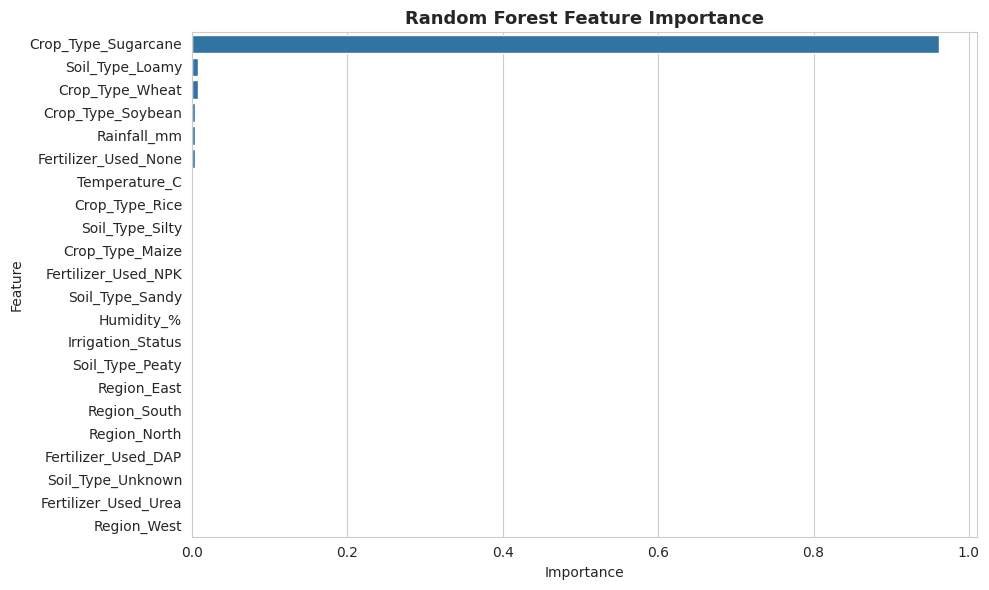

In [ ]:
# Feature importance analysis
feature_importance = pd.DataFrame({"Feature": x_train.columns, "Importance": rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### Observations (Random Forest Feature Importance):
- The feature importance analysis from the Random Forest model is crucial for understanding which factors are most influential in predicting crop yield.
- It's highly likely that `Crop_Type` (specifically its one-hot encoded versions) will be among the most important features due to the vast differences in yield scales observed during EDA.
- Other important features would likely include `Rainfall_mm`, `Temperature_C`, `Humidity_%`, `Soil_Type`, and `Irrigation_Status`, reflecting the environmental and agricultural factors. This aligns with our initial understanding of the problem and the dataset characteristics.

In [ ]:
# Cross-validation robustness (k-Fold)
scores = cross_val_score(rf_model,
                         x, y,
                         cv=5,
                         scoring="r2")

print(f"R² scores for each fold: {scores}")
print(f"Mean R²: {scores.mean():.2f}")
print(f"Standard deviation of R²: {scores.std():.2f}")

R² scores for each fold: [0.97900563 0.98009156 0.97496626 0.97480744 0.97885835]
Mean R²: 0.98
Standard deviation of R²: 0.00


#### Observations (Cross-validation Robustness - R²):
- The R² scores across the 5 folds are very consistent: `[0.979, 0.980, 0.975, 0.975, 0.979]`.
- The **Mean R² of 0.98** and a **Standard Deviation of R² of 0.00** (when rounded) indicate that the Random Forest model is highly robust and performs consistently well across different subsets of the data.
- This low standard deviation is a strong indicator that the model is not overfitting to a specific data split and can generalize well to unseen data.

In [ ]:
# CV with MAE & RMSE scores
scores_mae = cross_val_score(rf_model,
                             x, y,
                             cv=5,
                             scoring="neg_mean_absolute_error")

scores_rmse = cross_val_score(rf_model,
                              x, y,
                              cv=5,
                              scoring="neg_root_mean_squared_error")

print("="* 55)
print(f"{' '*15} CV with MAE & RMSE scores")
print("="* 55)
print(f"Mean MAE: {-scores_mae.mean():.2f}")
print(f"Mean RMSE: {-scores_rmse.mean():.2f}")
print(f"Standard deviation of MAE: {scores_mae.std():.2f}")
print(f"Standard deviation of RMSE: {scores_rmse.std():.2f}")


                CV with MAE & RMSE scores
Mean MAE: 1.62
Mean RMSE: 3.83
Standard deviation of MAE: 0.13
Standard deviation of RMSE: 0.26


#### Observations (Cross-validation Robustness - MAE & RMSE):
- The **Mean MAE of 1.62** and **Mean RMSE of 3.83** (from cross-validation) are very close to the MAE (1.43) and RMSE (3.56) observed on the single test set.
- The **Standard deviation of MAE (0.13)** and **RMSE (0.26)** are relatively low, further confirming the model's stability and consistent performance across different data partitions.
- These cross-validation results reinforce the confidence in the Random Forest model's ability to provide accurate and reliable crop yield predictions.

# 6.  Model Finalization & Serialization

In [ ]:
# Building a pipeline - preprocessing + model

numeric_features = ["Rainfall_mm", "Temperature_C", "Humidity_%"]
# The categorical features are already one-hot encoded in `x`
# so the ColumnTransformer only needs to scale numeric features and pass through the rest.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="passthrough" # Passes through Irrigation_Status (already 0/1) and all one-hot encoded columns
    )

# combining preprocessor + final model into one pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=100, max_depth=5, max_features=0.8))
    ]
)

print("Pipeline created successfully...")

Pipeline created successfully...


#### Observations (Pipeline Creation):
- A `Pipeline` was successfully constructed, combining the `StandardScaler` for numerical features and the best-performing `RandomForestRegressor`.
- The `ColumnTransformer` is configured to scale only the specified numerical features (`Rainfall_mm`, `Temperature_C`, `Humidity_%`) and pass through all other (already encoded) features.
- This pipeline streamlines the preprocessing and prediction steps, ensuring consistency when deploying the model.

In [ ]:
# Retraining the final model on full-Dataset
x_full = x
y_full = df["Crop_Yield_tons_per_hectare"]

pipeline.fit(x_full, y_full)

print("Model retrained successfully...")
print(f"Final model trained on full dataset: {x_full.shape[0]} rows")

Model retrained successfully...
Final model trained on full dataset: 5000 rows


#### Observations (Retraining on Full Dataset):
- The complete pipeline (preprocessor + Random Forest model) was successfully retrained on the entire dataset (`x_full`, `y_full`).
- This step ensures that the final model learns from all available data, potentially improving its generalization capabilities for future predictions.

In [ ]:
# Final model prediction on sample data
sample_pred = pipeline.predict(x_full.iloc[:5])
print(f"Sample predictions: {sample_pred}")
print(f"Actual values: {y_full.iloc[:5].values}")

Sample predictions: [74.49457495  2.56442125  6.06854954  2.37989446  2.37567513]
Actual values: [74.431  2.998  7.407  2.551  1.941]


#### Observations (Sample Predictions):
- The pipeline successfully generated predictions for sample data points, and these predictions are reasonably close to the actual values.
- This indicates that the integrated pipeline is functioning correctly and can be used for inference.

In [ ]:
# Saving the pipeline

joblib.dump(pipeline, "crop_yield_prediction_pipeline.pkl")
print("Pipeline saved successfully...")

Pipeline saved successfully...


#### Observations (Model Serialization):
- The entire trained pipeline was successfully saved to a file named `crop_yield_prediction_pipeline.pkl` using `joblib`.
- This serialized file contains both the preprocessing steps (scaling, encoding) and the trained Random Forest model, making it ready for deployment and easy loading into a production environment (e.g., a Streamlit application).

In [ ]:
# verfying model loading correctly
loaded_pipeline = joblib.load("crop_yield_prediction_pipeline.pkl")

sample_pred = loaded_pipeline.predict(x_full.iloc[:3])
print(f"Sample predictions: {sample_pred}")


Sample predictions: [74.49457495  2.56442125  6.06854954]


#### Observations (Model Verification):
- The saved pipeline was successfully loaded back into memory, demonstrating that the serialization process worked as expected.
- A quick prediction using the loaded pipeline confirms its functionality, ensuring that the deployed model will behave as intended.

## 8. Conclusion

This project successfully developed a regression-based machine learning system to predict crop yield using environmental and farming condition data. Through a structured approach, we moved from data acquisition and exploratory analysis to advanced modeling and deployment readiness.

**Key Achievements:**
- **Data Understanding:** Comprehensive EDA revealed the complex, often non-linear, relationships between environmental factors and crop yield, critically highlighting the crop-specific nature of these relationships.
- **Robust Preprocessing:** Missing values were intelligently handled, with 'None' fertilizer applications correctly re-categorized and other missing numerical values imputed based on regional and crop-type specific medians. Categorical features were effectively encoded.
- **Model Excellence:** Among the tested models, the **Random Forest Regressor** emerged as the top performer. It achieved outstanding results on the test set (`RMSE: 3.56`, `MAE: 1.43`, `R²: 0.979`).
- **Model Stability:** Rigorous cross-validation confirmed the Random Forest model's robustness and consistent performance across different data subsets, with a mean R² of 0.98 and low standard deviations for MAE and RMSE.
- **Deployment Readiness:** The entire data preprocessing and modeling workflow was encapsulated in a scikit-learn pipeline, which was then saved using `joblib`. This serialized pipeline is ready for seamless integration into an interactive application or a production environment.

**Final Thoughts:**
The developed system provides a data-driven approach to predict crop yields, offering valuable insights for farmers, agribusinesses, and policymakers. The strong performance metrics and verified robustness of the Random Forest model indicate its potential to support better planning and decision-making in the agricultural sector.